# Chargement des dataset Input_Space et Output_Space

In [2]:
import pandas as pd
input_space = pd.read_excel('Input_Space.xlsx',engine='openpyxl')
output_space = pd.read_excel('Output_Space.xlsx',engine='openpyxl')
########  Filtrer les données avec la Variance   
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold() # Threshold default is 0
_ = vt.fit(input_space)
var_vector_mask = vt.get_support()
    #var_vector_mask 
input_space = input_space.loc[:, var_vector_mask]
col_names=input_space.columns

In [3]:
#####  Creation des fakes variables 
import numpy as np
Vars=input_space.columns
input_space[[v + "_fake" for v in Vars]]=input_space.iloc[np.random.permutation(input_space.index)].reset_index(drop=True)
input_space

,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed,RM_1_fake,RM_2_fake,RM_3_fake,RM_4_fake,PR_temp_fake,PR_speed_fake
0,0.5,4.0,3.5,10,23,50,0.5,4.0,3.5,10,23,50
1,1.0,0.5,5.0,15,18,40,1.0,1.0,1.5,10,18,50
2,1.5,1.0,2.0,7,25,70,3.5,3.5,4.0,7,23,25
3,2.0,1.5,3.5,10,30,25,1.5,1.0,2.0,7,25,70
4,3.5,2.0,0.5,9,23,80,2.0,1.5,3.5,10,30,25
5,0.5,0.5,1.0,12,27,90,1.0,0.5,5.0,15,18,40
6,1.0,1.0,1.5,10,18,50,3.5,2.0,0.5,9,23,80
7,1.5,1.5,2.0,13,32,40,0.5,0.5,1.0,12,27,90
8,2.0,2.0,5.0,14,30,70,1.5,1.5,2.0,13,32,40
9,3.5,3.5,4.0,7,23,25,5.0,0.0,0.5,6,27,80


In [4]:
###### Application de la standardisation avec “StandardScaler” dans le package #preprocessing.
import pandas as pd    
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
output_space = pd.DataFrame(ss.fit_transform(output_space),columns =output_space.columns)
input_space = pd.DataFrame(ss.fit_transform(input_space),columns =input_space.columns)

In [5]:
###### Fonction permettant de comparer les variables avec leur fakes
def ft_from_fake(ft_input,var_names):
    ft=ft_input
    for i in var_names: 
        #print(ft.loc[i,'feature_importance_vals']
        if   ft.loc[i,col] <= ft.loc[i+"_fake",col]:
            ft.loc[i,col]=0
            ft.drop(ft.tail(len(col_names)).index,inplace = True)
            return ft

In [7]:
###############  Random Forest model and SHAP for Cost prediction
     ##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import shap
import numpy as np
import matplotlib.pyplot as plt
feature_importance=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
for  col in list(output_space.columns.values):
    Output= output_space.to_dict('series')
    #print(Output[col])
    X = input_space
    model = RandomForestRegressor(n_estimators =100, random_state =0)
    Score_col=cross_val_score(model, X ,Output[col], cv=10, scoring=make_scorer(mean_squared_error))
    model_col=model.fit(X, Output[col])  
    ##### SHAP explaination
    shap_values_col= shap.TreeExplainer(model_col).shap_values(X)
    vals_col= np.abs(shap_values_col.mean(0))
    feature_importance[col]=vals_col
    
########################### SHAP VALUES IMPORTANCE DATAFRAME
ft_from_fake(feature_importance,col_names)
feature_importance = 1.15*feature_importance
feature_importance[feature_importance > 1] = 1
feature_importance

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
RM_1,0.006065,0.033577,0.000641,0.002775,0.018465,0.002477,0.004769,0.006127,0.006713
RM_2,0.002977,0.007019,0.002493,0.003583,0.000000,0.003818,0.008120,0.091470,0.010443
RM_3,0.021443,0.003266,0.015693,0.003892,0.006612,0.007348,0.008994,0.015212,0.000000
RM_4,0.012341,0.004838,0.062501,0.024619,0.018870,0.016069,0.001693,0.002100,0.003450
PR_temp,0.003918,0.004040,0.001346,0.009972,0.002422,0.010696,0.006581,0.018117,0.001625
PR_speed,0.001612,0.002411,0.007140,0.012253,0.001837,0.012612,0.007569,0.003227,0.015564


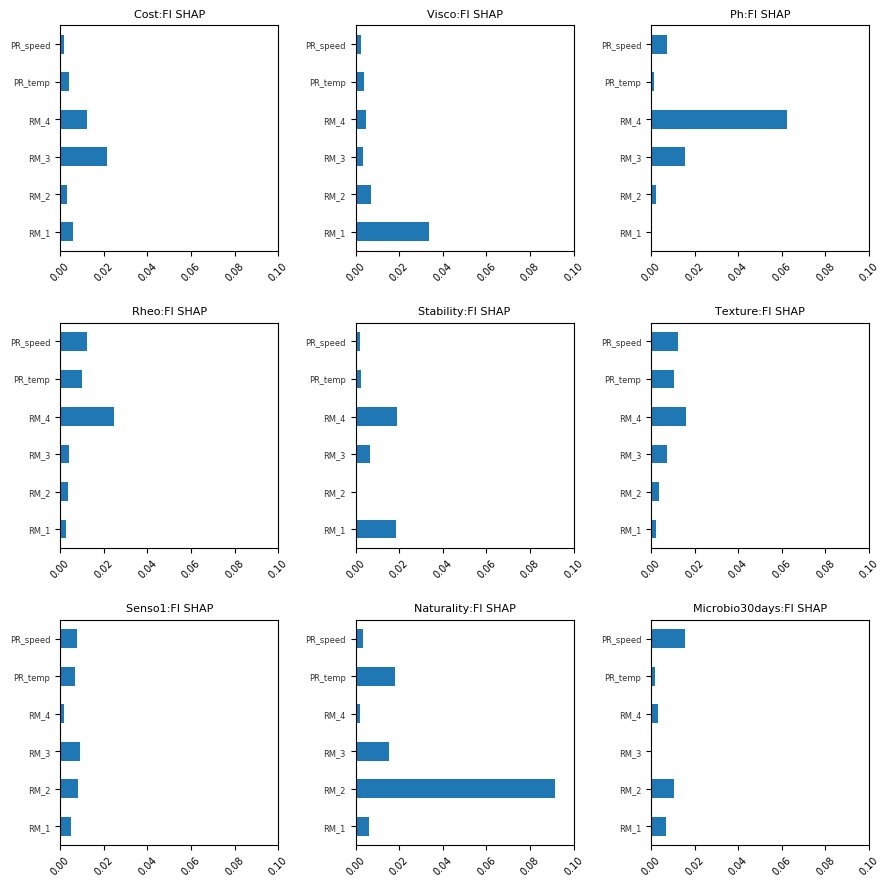

In [18]:
import pandas as pd 
import matplotlib.pyplot as plt 
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(3, 3, i+1)
    feature_importance[col].plot(kind='barh')
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 0.1])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)   
plt.show()


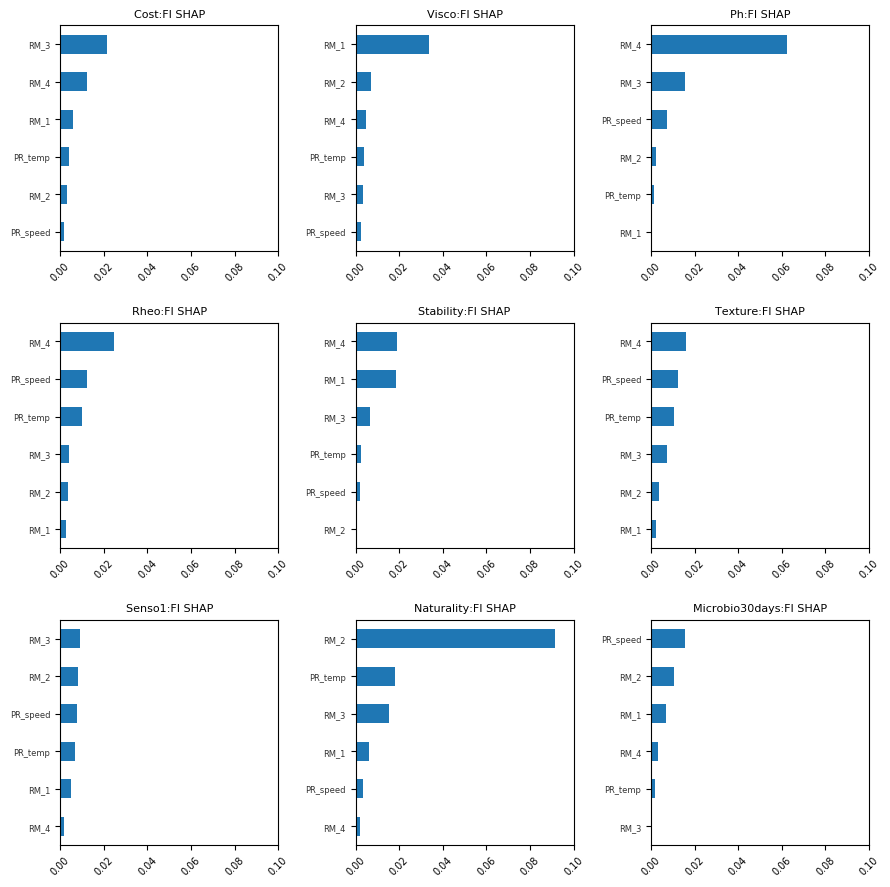

In [20]:
import pandas as pd 
import matplotlib.pyplot as plt 
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(3, 3, i+1)
    feature_importance[col].sort_values().plot(kind='barh')
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 0.1])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)   
plt.show()


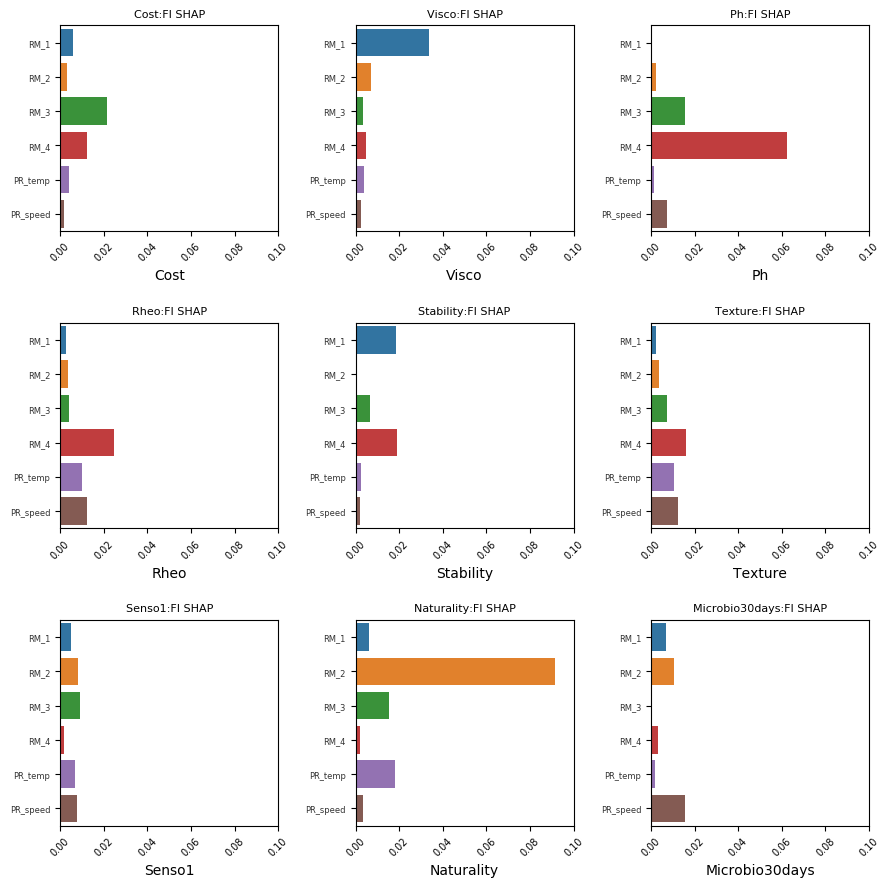

In [21]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(3, 3, i+1)
    sns.barplot(x=feature_importance[col], y=feature_importance.index)
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0,0.1])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)
plt.show()

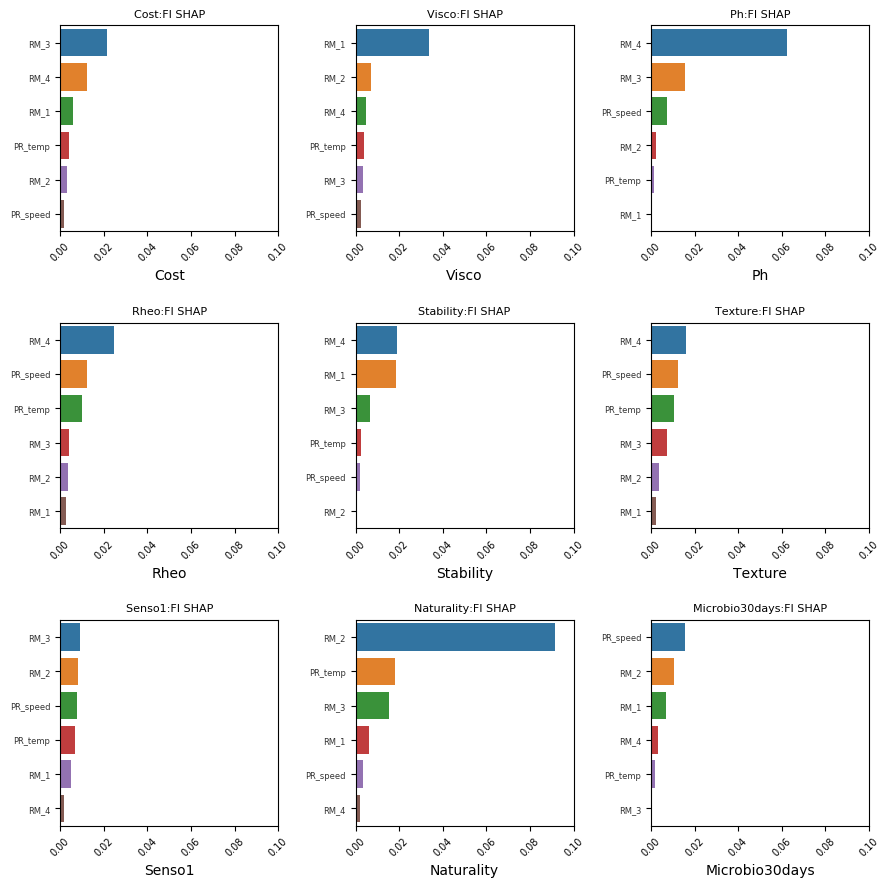

In [23]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(3, 3, i+1)
    sns.barplot(x=feature_importance[col], y=feature_importance.index, order=feature_importance[col].sort_values(ascending = False).index)
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 0.1])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)
plt.show()


In [8]:
def dataF(x,y,names):
    res = []

    for t in zip(x,y):
        res.append(t)

    return pd.DataFrame(res,columns=names)

In [ ]:
# shap_means=pd.concat([fi_col,fi_col,fi_col,fi_col,fi_col,fi_col,fi_col,fi_col,fi_col],axis=1,join='inner',sort=False)
    #shap_means=pd.concat([fi_col,fi_col],ignore_index=False,sort=False,axis=1,join='inner')  
    #shap_means= pd.concat([fi_col],axis=1,ignore_index=False)   
    #shap_means
  ######## Dataset of means shap values for each output columns
    #shap_means[list(output_space.columns )]=fi_col
    #shap_means= pd.concat([fi_col],axis=0,join='inner',sort=False)       
    #shap_means.columns=output_space.columns    

In [ ]:
########################################"" Visualisation 
        import pandas as pd 
        import matplotlib.pyplot as plt 
        fig = plt.figure(figsize = (9, 9))
        for i, col in enumerate(output_space.columns):
        ax = fig.add_subplot(3, 3, i+1)
        shap_values[col].plot(kind='barh')
        plt.xticks(fontsize=7,rotation=45)
        plt.yticks(fontsize=6,color ='0.2')
        plt.xlim([0, 1])
        plt.title(col+ ":FI SHAP",fontsize=8)
        plt.tight_layout(pad=1,h_pad=1.4)   
        plt.show()
